In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import kagglehub

path = kagglehub.dataset_download("patrickfleith/nasa-battery-dataset")
print("Path to dataset files:", path)

inner_path = os.path.join(path, "cleaned_dataset")
data_path  = os.path.join(inner_path, "data")

metadata_path = os.path.join(inner_path, "metadata.csv")
meta_df = pd.read_csv(metadata_path)
print("Metadata shape:", meta_df.shape)
meta_df.head()




Using Colab cache for faster access to the 'nasa-battery-dataset' dataset.
Path to dataset files: /kaggle/input/nasa-battery-dataset
Metadata shape: (7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [2]:

sample_file = os.listdir(data_path)[0]
sample_path = os.path.join(data_path, sample_file)
df = pd.read_csv(sample_path)
print("Sample file columns:", list(df.columns))
df.head()



Sample file columns: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time']


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.199816,-0.001737,24.562094,0.0004,0.000,0.000
1,4.199750,-0.000131,24.559681,0.0006,4.215,9.343
2,3.488788,-4.025638,24.711830,3.9950,1.541,19.671
3,3.450743,-4.023731,25.173478,3.9950,1.513,29.171
4,3.420290,-4.023544,25.733040,3.9950,1.487,38.750


In [3]:


from sklearn.linear_model import LinearRegression

discharge_df = meta_df[meta_df["type"] == "discharge"].copy()

# Keep only rows with valid Capacity
discharge_df["Capacity"] = pd.to_numeric(discharge_df["Capacity"], errors="coerce")
discharge_df = discharge_df[discharge_df["Capacity"] > 0].copy()

print("After capacity filter:", discharge_df.shape)
print("Batteries:", discharge_df["battery_id"].nunique())

# Cycle number per battery
discharge_df["cycle"] = discharge_df.groupby("battery_id").cumcount() + 1

# Total life and RUL
total_cycles            = discharge_df.groupby("battery_id")["cycle"].max()
discharge_df["total_life"] = discharge_df["battery_id"].map(total_cycles)
discharge_df["RUL"]        = discharge_df["total_life"] - discharge_df["cycle"]

# Capacity features
discharge_df["initial_capacity"] = (
    discharge_df.groupby("battery_id")["Capacity"].transform("first")
)
discharge_df["capacity_ratio"] = discharge_df["Capacity"] / discharge_df["initial_capacity"]
discharge_df["capacity_diff"]  = discharge_df.groupby("battery_id")["Capacity"].diff()

# Degradation slope (linear fit per battery)
slopes = {}
for battery in discharge_df["battery_id"].unique():
    bdata = discharge_df[discharge_df["battery_id"] == battery]
    X_lr  = bdata["cycle"].values.reshape(-1, 1)
    y_lr  = bdata["Capacity"].values
    lr    = LinearRegression()
    lr.fit(X_lr, y_lr)
    slopes[battery] = lr.coef_[0]

discharge_df["degradation_slope"] = discharge_df["battery_id"].map(slopes)

# FIX: Only drop NaN on the specific columns we use — NOT the whole dataframe
basic_cols = ["Capacity", "capacity_ratio", "capacity_diff", "degradation_slope", "RUL"]
discharge_df = discharge_df.dropna(subset=basic_cols).copy()
discharge_df = discharge_df.reset_index(drop=True)

print("\nAfter targeted dropna:", discharge_df.shape)
print("Unique batteries:", discharge_df["battery_id"].nunique())
discharge_df[["battery_id", "cycle", "Capacity", "RUL"]].head(10)




After capacity filter: (2750, 10)
Batteries: 34

After targeted dropna: (2716, 17)
Unique batteries: 34


,battery_id,cycle,Capacity,RUL
0,B0047,2,1.524366,67
1,B0047,3,1.508076,66
2,B0047,4,1.483558,65
3,B0047,5,1.467139,64
4,B0047,6,1.448858,63
5,B0047,7,1.445853,62
6,B0047,8,1.431118,61
7,B0047,9,1.419275,60
8,B0047,10,1.399997,59
9,B0047,11,1.388516,58


In [4]:


def extract_timeseries_features(file_path):
    try:
        df_cycle = pd.read_csv(file_path)

        discharge_time = df_cycle["Time"].iloc[-1] - df_cycle["Time"].iloc[0]
        temp_var       = df_cycle["Temperature_measured"].var()

        X_time = df_cycle["Time"].values.reshape(-1, 1)
        y_volt = df_cycle["Voltage_measured"].values
        lr_v   = LinearRegression()
        lr_v.fit(X_time, y_volt)
        voltage_slope = lr_v.coef_[0]

        v_std = df_cycle["Voltage_measured"].std()
        i_std = df_cycle["Current_measured"].std()
        internal_res_proxy = v_std / i_std if i_std != 0 else np.nan

        voltage_drop = (df_cycle["Voltage_measured"].iloc[0]
                        - df_cycle["Voltage_measured"].iloc[-1])
        mean_temp    = df_cycle["Temperature_measured"].mean()

        return discharge_time, temp_var, voltage_slope, internal_res_proxy, voltage_drop, mean_temp

    except:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan


print("Extracting time-series features... (this takes ~1-2 mins)")
feature_results = []
for idx, row in discharge_df.iterrows():
    file_path = os.path.join(data_path, row["filename"])
    ts_values = extract_timeseries_features(file_path)
    feature_results.append(ts_values)      # ← ONE append only, no features list here

ts_features_df = pd.DataFrame(
    feature_results,
    columns=[
        "avg_discharge_time", "temperature_variance", "voltage_slope",
        "internal_resistance_proxy", "voltage_drop", "mean_temperature"
    ]
)

# Merge — both are reset_index so rows align correctly
discharge_df = pd.concat([discharge_df.reset_index(drop=True), ts_features_df], axis=1)

# Rolling slope
discharge_df["rolling_slope_10"] = (
    discharge_df.groupby("battery_id")["Capacity"]
    .rolling(10)
    .apply(lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=False)
    .reset_index(level=0, drop=True)
)

# ── Save clean copy BEFORE final dropna (used for degradation plot) ──
# astype(str) strips Categorical dtype that causes ghost battery_id labels
discharge_df_clean = discharge_df.reset_index(drop=True).copy()
discharge_df_clean["battery_id"] = discharge_df_clean["battery_id"].astype(str)
discharge_df_clean["cycle"]      = pd.to_numeric(discharge_df_clean["cycle"],    errors="coerce")
discharge_df_clean["Capacity"]   = pd.to_numeric(discharge_df_clean["Capacity"], errors="coerce")
discharge_df_clean["RUL"]        = pd.to_numeric(discharge_df_clean["RUL"],      errors="coerce")
discharge_df_clean = discharge_df_clean.dropna(subset=["cycle", "Capacity", "RUL"]).copy()

print("discharge_df_clean shape:", discharge_df_clean.shape)
print("Batteries in clean copy:", discharge_df_clean["battery_id"].nunique())
print("Cycle range:", int(discharge_df_clean["cycle"].min()), "—", int(discharge_df_clean["cycle"].max()))




Extracting time-series features... (this takes ~1-2 mins)
discharge_df_clean shape: (2716, 24)
Batteries in clean copy: 34
Cycle range: 2 — 197


In [5]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "Capacity",
    "capacity_ratio",
    "capacity_diff",
    "degradation_slope",
    "avg_discharge_time",
    "temperature_variance",
    "voltage_slope",
    "internal_resistance_proxy",
    "voltage_drop",
    "mean_temperature",
    "rolling_slope_10"
]
target = "RUL"

# FIX: dropna only on features + target, not full dataframe
discharge_df = discharge_df.dropna(subset=features + [target]).copy()
discharge_df = discharge_df.reset_index(drop=True)

print("Final training shape:", discharge_df.shape)
print("Unique batteries:", discharge_df["battery_id"].nunique())

# Battery-wise split (avoids data leakage)
battery_ids = discharge_df["battery_id"].unique()
train_ids, test_ids = train_test_split(battery_ids, test_size=0.2, random_state=42)

train_df = discharge_df[discharge_df["battery_id"].isin(train_ids)]
test_df  = discharge_df[discharge_df["battery_id"].isin(test_ids)]

X_train = train_df[features]
y_train = train_df[target]
X_test  = test_df[features]
y_test  = test_df[target]

model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("\n=== Final Model (11 features) ===")
print("MAE:", round(mean_absolute_error(y_test, preds), 3))
print("R2 :", round(r2_score(y_test, preds), 3))




Final training shape: (2416, 24)
Unique batteries: 33

=== Final Model (11 features) ===
MAE: 9.351
R2 : 0.879


                  feature  importance
       avg_discharge_time    0.800583
         mean_temperature    0.048080
           capacity_ratio    0.041745
            voltage_slope    0.026139
        degradation_slope    0.024752
         rolling_slope_10    0.018405
                 Capacity    0.017468
     temperature_variance    0.008640
internal_resistance_proxy    0.005507
             voltage_drop    0.005226
            capacity_diff    0.003454


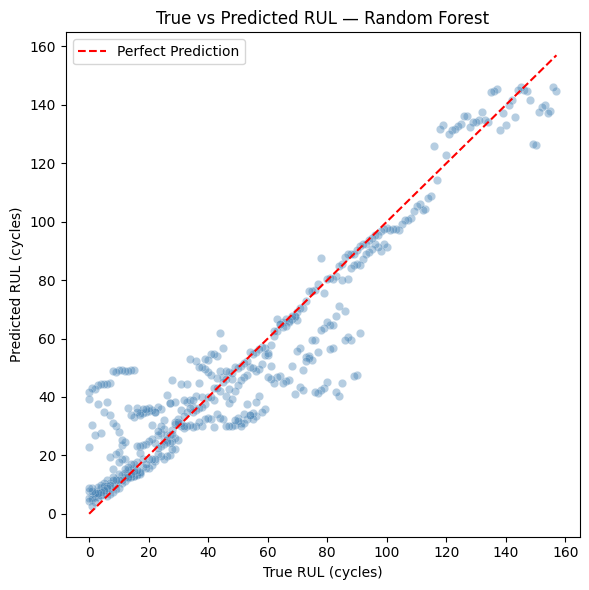

In [6]:

importance_df = pd.DataFrame({
    "feature":    features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)
print(importance_df.to_string(index=False))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.4, color="steelblue", edgecolors="white", linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel("True RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("True vs Predicted RUL — Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("true_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()



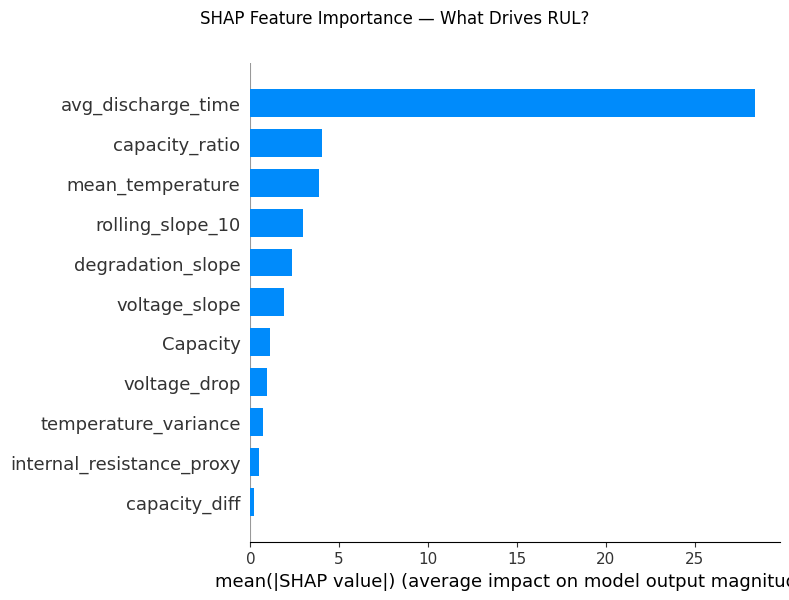

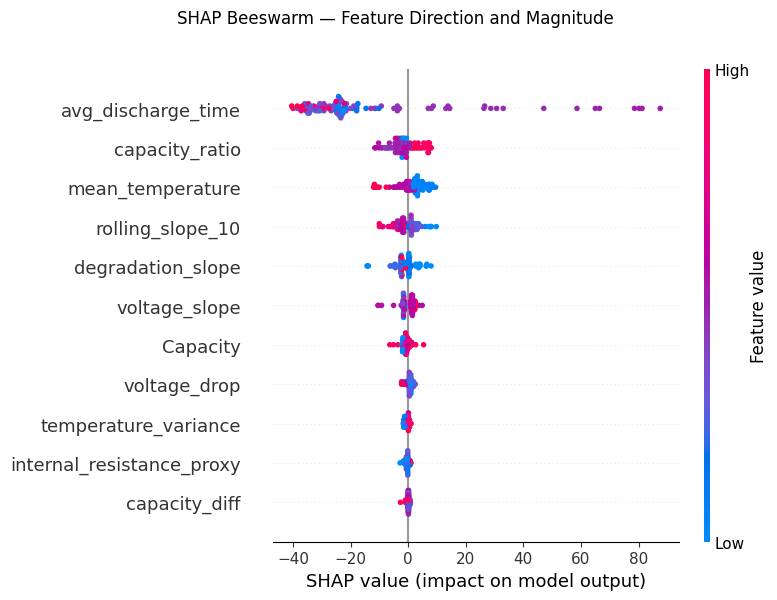

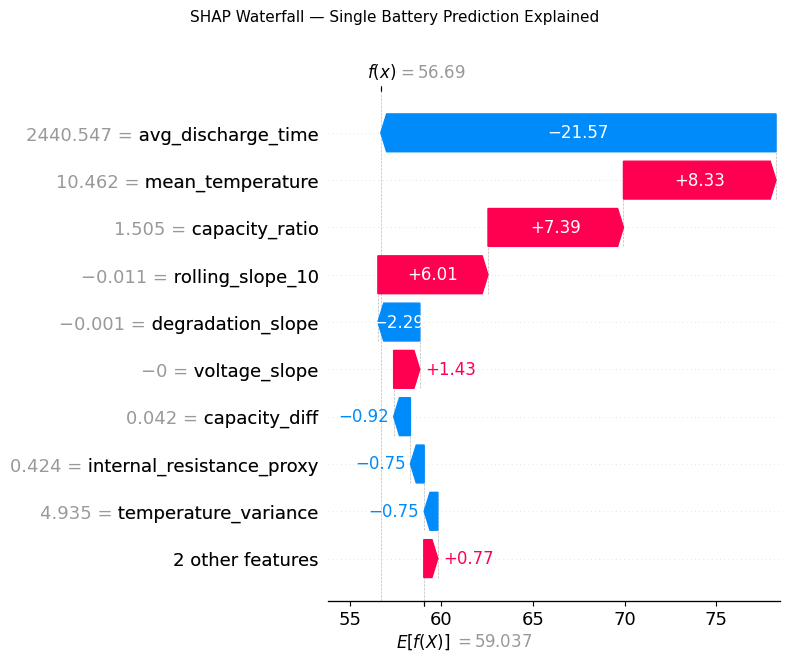

In [7]:


import shap

explainer     = shap.TreeExplainer(model)
X_test_sample = X_test.sample(min(100, len(X_test)), random_state=42)
shap_values   = explainer.shap_values(X_test_sample)

# Bar plot
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=False)
plt.gcf().suptitle('SHAP Feature Importance — What Drives RUL?', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Beeswarm plot
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.gcf().suptitle('SHAP Beeswarm — Feature Direction and Magnitude', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Waterfall (single battery explanation)
shap_explanation = shap.Explanation(
    values        = shap_values[0],
    base_values   = explainer.expected_value,
    data          = X_test_sample.iloc[0],
    feature_names = features
)
shap.plots.waterfall(shap_explanation, show=False)
plt.gcf().suptitle('SHAP Waterfall — Single Battery Prediction Explained', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()



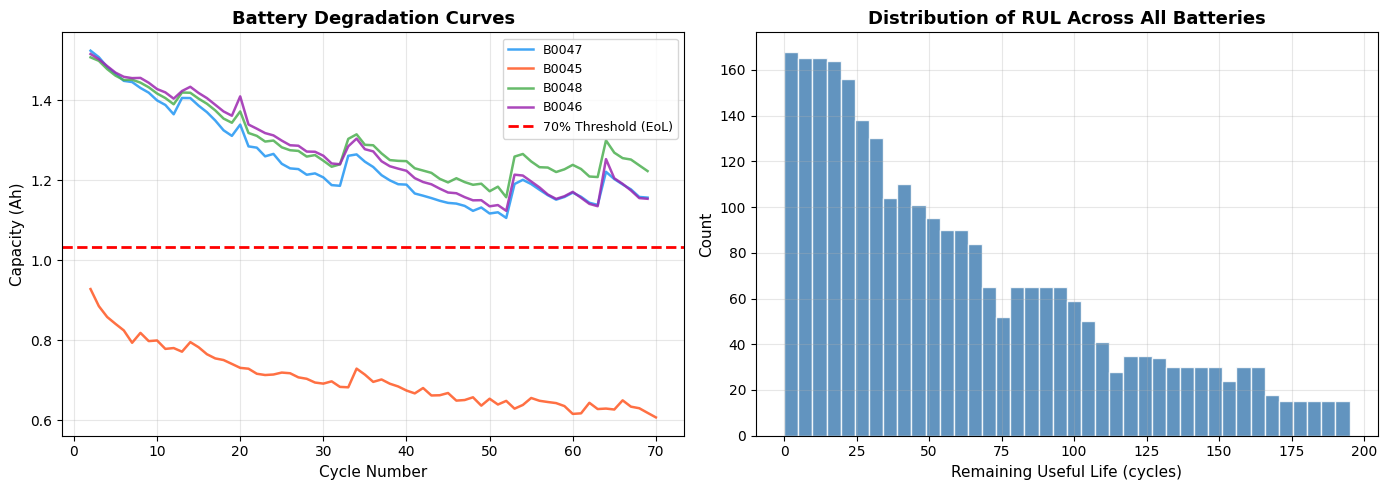

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_batteries = discharge_df_clean["battery_id"].unique()[:4]
colors = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0"]

for i, battery in enumerate(sample_batteries):
    bdf = discharge_df_clean[discharge_df_clean["battery_id"] == battery].copy()
    bdf = bdf.sort_values("cycle")
    axes[0].plot(bdf["cycle"], bdf["Capacity"],
                 label=str(battery), alpha=0.85, linewidth=1.8, color=colors[i % 4])

initial_cap = discharge_df_clean.groupby("battery_id")["Capacity"].first().mean()
axes[0].axhline(y=initial_cap * 0.70, color="red", linestyle="--",
                linewidth=2, label="70% Threshold (EoL)")
axes[0].set_xlabel("Cycle Number", fontsize=11)
axes[0].set_ylabel("Capacity (Ah)", fontsize=11)
axes[0].set_title("Battery Degradation Curves", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

rul_vals = discharge_df_clean["RUL"].dropna()
axes[1].hist(rul_vals, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Remaining Useful Life (cycles)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title("Distribution of RUL Across All Batteries", fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("degradation_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()




In [9]:

import joblib

joblib.dump({"model": model, "features": features}, "secondspark_full_pipeline.pkl")
print("Model saved: secondspark_full_pipeline.pkl")

sample_row = X_test.iloc[[0]]
actual_rul = round(float(y_test.iloc[0]), 1)
pred_rul   = round(float(model.predict(sample_row)[0]), 1)
print(f"Sanity check — Actual RUL: {actual_rul}  |  Predicted RUL: {pred_rul}")



Model saved: secondspark_full_pipeline.pkl
Sanity check — Actual RUL: 29.0  |  Predicted RUL: 22.3


In [10]:

from google.colab import files

sample_csv    = X_test.sample(10, random_state=99).copy()
true_rul_vals = y_test.loc[sample_csv.index].values
preds_check   = model.predict(sample_csv[features])

sample_csv.to_csv("sample_test_batteries.csv", index=False)

compare_df = pd.DataFrame({
    "battery_index" : range(1, 11),
    "true_rul"      : [round(float(r), 1) for r in true_rul_vals],
    "expected_pred" : [round(float(p), 1) for p in preds_check]
})

print("Verification table — predicted_rul should match expected_pred when you re-upload:\n")
display(compare_df)
print("\nDownloading sample_test_batteries.csv...")
files.download("sample_test_batteries.csv")


Verification table — predicted_rul should match expected_pred when you re-upload:



,battery_index,true_rul,expected_pred
0,1,64.0,65.1
1,2,82.0,80.4
2,3,33.0,30.0
3,4,47.0,30.1
4,5,2.0,26.9
5,6,37.0,36.2
6,7,101.0,97.2
7,8,20.0,35.0
8,9,21.0,30.6
9,10,40.0,39.9


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

from google.colab import files
import io

def predict_rul_from_csv():
    print("Upload your CSV file (needs the 11 feature columns)...")
    uploaded = files.upload()

    for filename, content in uploaded.items():
        print(f"\nProcessing: {filename}")
        df_input = pd.read_csv(io.BytesIO(content))

        missing = [f for f in features if f not in df_input.columns]
        if missing:
            print(f"\nERROR — Missing columns: {missing}")
            print(f"Your CSV has: {list(df_input.columns)}")
            return None

        X_input   = df_input[features].copy()
        rul_preds = model.predict(X_input)

        results = []
        for i, rul in enumerate(rul_preds):
            rul = max(0.0, round(float(rul), 1))
            results.append({"battery_index": i + 1, "predicted_rul": rul})

        result_df = pd.DataFrame(results)
        print(f"\n{'='*45}")
        print(f"  SecondSpark AI — RUL Predictions ({len(results)} batteries)")
        print(f"{'='*45}")
        display(result_df)
        print(f"\nAverage RUL : {round(result_df['predicted_rul'].mean(), 1)} cycles")
        print(f"Min RUL     : {result_df['predicted_rul'].min()} cycles")
        print(f"Max RUL     : {result_df['predicted_rul'].max()} cycles")
        return result_df

result_df = predict_rul_from_csv()

Upload your CSV file (needs the 11 feature columns)...
